# RAG Pipeline Demo

## What this notebook does

We build a full RAG pipeline over **5 arXiv papers** pre-fetched in `../arxivx/papers/`:

```
arxivx/papers/texts/*.txt
        │
        ▼
    [ CHUNK ]  RecursiveCharacterTextSplitter  (500 chars, 100 overlap)
        │
        ▼
    [ EMBED ]  sentence-transformers  all-MiniLM-L6-v2  (local, no API key)
        │
        ▼
    [ STORE ]  ChromaDB  persisted to ./chroma_db/
        │
user query ──▶ embed ──▶ [ RETRIEVE ] top-k chunks
                                  │
                                  ▼
                       [ GENERATE ]  Ollama  llama3.2:3b
                                  │
                                  ▼
                               answer
```


In [1]:
! uv pip install -q chromadb sentence-transformers langchain-text-splitters

In [2]:
import json
from pathlib import Path

import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
from langchain_text_splitters import RecursiveCharacterTextSplitter
from openai import OpenAI

# Paths
ARXIVX_BASE  = Path("../arxivx")
CATALOG_PATH = ARXIVX_BASE / "papers" / "catalog.json"
CHROMA_PATH  = Path("./chroma_db")
COLLECTION   = "arxiv_papers"

# Chunking settings
CHUNK_SIZE    = 500   # ~100-120 tokens
CHUNK_OVERLAP = 150

# How many chunks to retrieve per query
TOP_K = 4

# Ollama local server
OLLAMA_BASE  = "http://localhost:11434/v1"
OLLAMA_MODEL = "llama3.2:3b"

/Users/makis/lectures/Εφαρμογες Τεχνητης Νοημοσυνης/code/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Load Papers

Read `catalog.json` to discover all papers, then load each paper's full extracted text and
its metadata JSON.  The catalog and text files were produced by the
`../arxivx/01_fetch_arxiv_papers*.ipynb` notebooks.

In [3]:
def load_papers(catalog_path: Path) -> list[dict]:
    catalog = json.loads(catalog_path.read_text())
    papers = []
    for entry in catalog:
        # paths in catalog.json are relative to arxivx/  e.g. "papers/texts/xxx.txt"
        txt_file  = ARXIVX_BASE / entry["txt_path"]
        meta_file = ARXIVX_BASE / entry["meta_path"]
        text      = txt_file.read_text(encoding="utf-8")
        metadata  = json.loads(meta_file.read_text())
        authors   = entry["authors"]
        papers.append({
            "arxiv_id": entry["arxiv_id"],
            "title":    entry["title"],
            "authors":  ", ".join(authors[:3]) + (" et al." if len(authors) > 3 else ""),
            "abstract": metadata.get("abstract", ""),
            "text":     text,
        })
    return papers


papers = load_papers(CATALOG_PATH)

print(f"Loaded {len(papers)} papers:\n")
for p in papers:
    print(f"  [{p['arxiv_id']}]  {p['title']}")
    print(f"                   {p['authors']}")
    print(f"                   {len(p['text']):,} chars\n")

Loaded 100 papers:

  [2604.12128]  When Self-Reference Fails to Close: Matrix-Level Dynamics in Large Language Models
                   Ji Ho Bae
                   43,411 chars

  [2604.12138]  Beyond Factual Grounding: The Case for Opinion-Aware Retrieval-Augmented Generation
                   Aditya Agrawal, Alwarappan Nakkiran, Darshan Fofadiya et al.
                   72,881 chars

  [2604.12162]  AlphaEval: Evaluating Agents in Production
                   Pengrui Lu, Bingyu Xu, Wenjun Zhang et al.
                   108,996 chars

  [2604.12195]  Representing expertise accelerates learning from pedagogical interaction data
                   Dhara Yu, Karthikeya Kaushik, Bill D. Thompson
                   31,018 chars

  [2604.12231]  Thought-Retriever: Don't Just Retrieve Raw Data, Retrieve Thoughts for Memory-Augmented Agentic Systems
                   Tao Feng, Pengrui Han, Guanyu Lin et al.
                   125,802 chars

  [2604.12426]  Do Transformers Use their De

## Step 2 — Chunk Text

LLMs and embedding models have context limits.  We split each paper into overlapping windows so that:
- each chunk fits comfortably inside the embedding model's 512-token limit,
- adjacent chunks share an overlap region to prevent a sentence being cut across two chunks
  with neither side having full context.

`RecursiveCharacterTextSplitter` tries split points in this order:
`\n\n` → `\n` → `.` → ` ` → characters, keeping pieces as semantically coherent as possible.

In [4]:
def chunk_papers(papers: list[dict]) -> list[dict]:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
    )
    chunks = []
    for paper in papers:
        pieces = splitter.split_text(paper["text"])
        for i, piece in enumerate(pieces):
            chunks.append({
                "id":        f"{paper['arxiv_id']}_chunk_{i}",
                "text":      piece,
                "arxiv_id":  paper["arxiv_id"],
                "title":     paper["title"],
                "authors":   paper["authors"],
                "chunk_idx": i,
            })
    return chunks


chunks = chunk_papers(papers)

print(f"Total chunks : {len(chunks)}")
print(f"Avg length   : {sum(len(c['text']) for c in chunks) // len(chunks)} chars")
print(f"\nExample — paper 0, chunk 2:\n")
print(chunks[2]["text"])

Total chunks : 18654
Avg length   : 450 chars

Example — paper 0, chunk 2:

on key collapse-related metrics, and on sev-
eral such metrics can be as stable as factual
controls. Instead, instability concentrates
in prompts that induce what we term non-
closing truth recursion (NCTR)—truth-value
computations that admit no finite-depth reso-
lution. NCTR prompts produce anomalously
elevated attention effective rank—indicating
attention reorganization with global dis-
persion rather than simple concentration
collapse—and key collapse-related metrics


## Step 3 — Embed & Store in ChromaDB

We use **`all-MiniLM-L6-v2`** — a fast, compact model (80 MB) that produces 384-dimensional embeddings.
ChromaDB wraps the model and handles the similarity index internally.

**The index is persisted to `./chroma_db/`**.  On re-runs, if the collection already has the correct
number of chunks, embedding is skipped automatically.

In [5]:
embedding_fn = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

client     = chromadb.PersistentClient(path=str(CHROMA_PATH))
collection = client.get_or_create_collection(
    name=COLLECTION,
    embedding_function=embedding_fn,
    metadata={"hnsw:space": "cosine"},
)

if collection.count() == len(chunks):
    print(f"Collection already contains {collection.count()} chunks — skipping re-indexing.")
else:
    # Wipe any partial state before a fresh upsert
    existing = collection.get()["ids"]
    if existing:
        collection.delete(ids=existing)

    batch_size = 64
    for start in range(0, len(chunks), batch_size):
        batch = chunks[start : start + batch_size]
        collection.add(
            ids       = [c["id"]   for c in batch],
            documents = [c["text"] for c in batch],
            metadatas = [
                {
                    "arxiv_id":  c["arxiv_id"],
                    "title":     c["title"],
                    "authors":   c["authors"],
                    "chunk_idx": c["chunk_idx"],
                }
                for c in batch
            ],
        )
        end = min(start + batch_size, len(chunks))
        print(f"  Indexed chunks {start}–{end - 1}  ({end}/{len(chunks)})")

    print(f"\nDone — {collection.count()} chunks stored in collection '{COLLECTION}'.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15721.01it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Indexed chunks 0–63  (64/18654)
  Indexed chunks 64–127  (128/18654)
  Indexed chunks 128–191  (192/18654)
  Indexed chunks 192–255  (256/18654)
  Indexed chunks 256–319  (320/18654)
  Indexed chunks 320–383  (384/18654)
  Indexed chunks 384–447  (448/18654)
  Indexed chunks 448–511  (512/18654)
  Indexed chunks 512–575  (576/18654)
  Indexed chunks 576–639  (640/18654)
  Indexed chunks 640–703  (704/18654)
  Indexed chunks 704–767  (768/18654)
  Indexed chunks 768–831  (832/18654)
  Indexed chunks 832–895  (896/18654)
  Indexed chunks 896–959  (960/18654)
  Indexed chunks 960–1023  (1024/18654)
  Indexed chunks 1024–1087  (1088/18654)
  Indexed chunks 1088–1151  (1152/18654)
  Indexed chunks 1152–1215  (1216/18654)
  Indexed chunks 1216–1279  (1280/18654)
  Indexed chunks 1280–1343  (1344/18654)
  Indexed chunks 1344–1407  (1408/18654)
  Indexed chunks 1408–1471  (1472/18654)
  Indexed chunks 1472–1535  (1536/18654)
  Indexed chunks 1536–1599  (1600/18654)
  Indexed chunks 1600–1663

## Step 4 — Retrieve Relevant Chunks

Given a user query, ChromaDB:
1. Embeds the query with the **same** `all-MiniLM-L6-v2` model used during indexing.
2. Computes cosine similarity between the query vector and every stored chunk vector.
3. Returns the **top-k** most similar chunks along with their metadata and distance scores.

ChromaDB returns *distances* (lower = more similar for cosine space), so we convert:
`similarity = 1 − distance`.

In [6]:
def retrieve(query: str, n: int = TOP_K) -> list[dict]:
    results = collection.query(query_texts=[query], n_results=n)
    hits = []
    for doc, meta, dist in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0],
    ):
        hits.append({
            "text":      doc,
            "title":     meta["title"],
            "arxiv_id":  meta["arxiv_id"],
            "authors":   meta["authors"],
            "chunk_idx": meta["chunk_idx"],
            "score":     round(1 - dist, 4),
        })
    return hits


# Quick test
test_query = "How does a spiking neural network work?"
hits = retrieve(test_query)

print(f"Query: {test_query}\n")
for i, h in enumerate(hits, 1):
    print(f"[{i}] score={h['score']}  [{h['arxiv_id']}] chunk {h['chunk_idx']}")
    print(f"     {h['title'][:65]}...")
    print(f"     {h['text'][:120]}...\n")

Query: How does a spiking neural network work?

[1] score=0.5686  [2604.22050] chunk 167
     LayerBoost: Layer-Aware Attention Reduction for Efficient LLMs...
     Koh, Ali Farhadi, Noah A. Smith, and Hannaneh Hajishirzi. Olmo 3, 2025. URL https:
//arxiv.org/abs/2512.13961.
Yuqi Pan,...

[2] score=0.455  [2604.22345] chunk 99
     Preference Heads in Large Language Models: A Mechanistic Framewor...
     Processing Systems 2024, NeurIPS 2024, Vancouver,
BC, Canada, December 10 - 15, 2024.
Aryo Pradipta Gema, Chen Jin, Ahme...

[3] score=0.4332  [2604.17823] chunk 57
     A novel LSTM music generator based on the fractional time-frequen...
     hidden states are calculated using the following
equation:
ht = f(Whhht−1 + Wxhxt + bh)
where Whh and Wxh are the weight...

[4] score=0.4314  [2604.23862] chunk 50
     Graph Memory Transformer (GMT)...
     At a high level, the memory cell computes two soft memory states for
each token: a source state, which describes where t...



## Step 4b — Visualise Embeddings in 2-D

Each chunk is a 384-dimensional vector. We can't plot 384 dimensions, so we use **t-SNE** to project them down to 2D while preserving local neighbourhood structure.



In [ ]:
! uv pip install matplotlib

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12052.26it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 155 texts …


Batches: 100%|██████████| 5/5 [00:00<00:00,  5.07it/s]


Running t-SNE …


/var/folders/z3/g_7hw3_j5pg33fqxp2ntmttc0000gn/T/ipykernel_39687/2270014259.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = plt.cm.get_cmap("tab10", len(paper_ids))


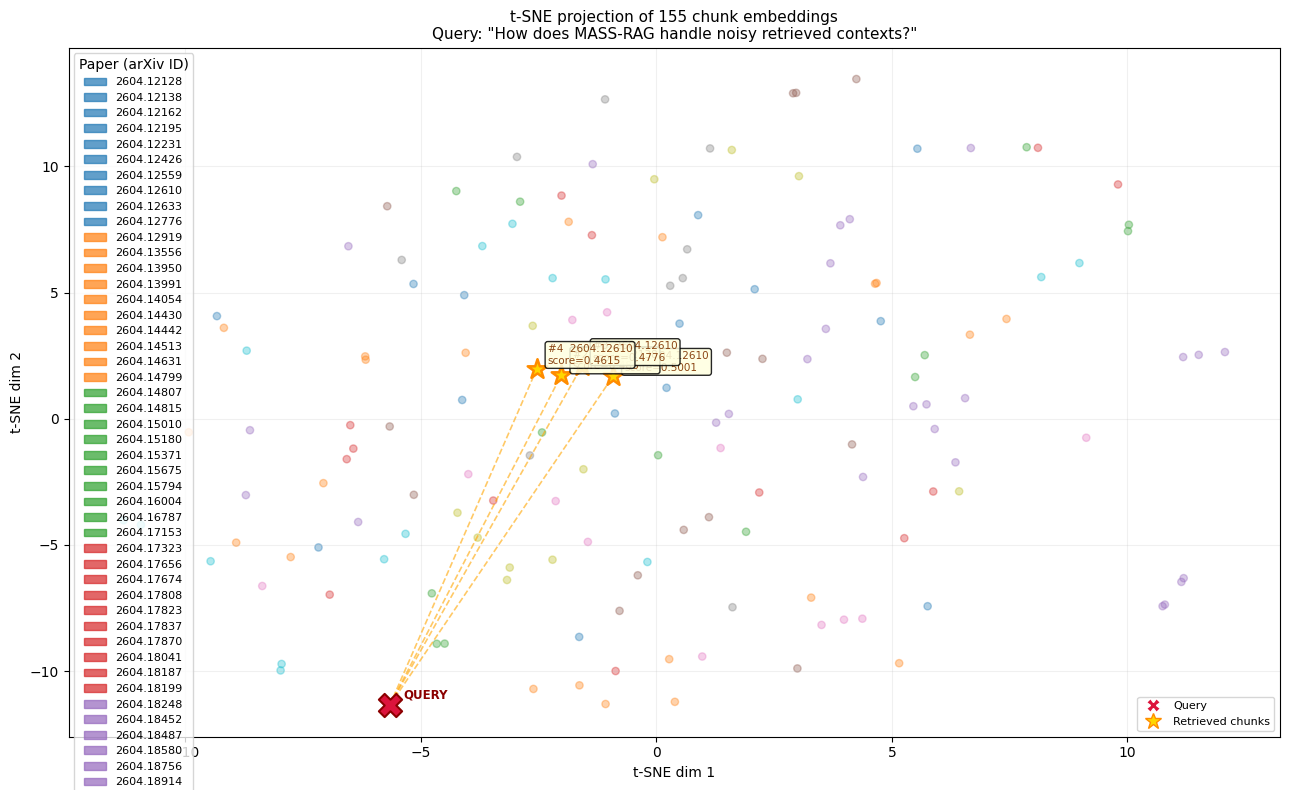

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

VIZ_QUERY   = "How does MASS-RAG handle noisy retrieved contexts?"
SAMPLE_SIZE = 150
RANDOM_SEED = 42

model = SentenceTransformer("all-MiniLM-L6-v2")

random.seed(RANDOM_SEED)
sample_chunks = random.sample(chunks, min(SAMPLE_SIZE, len(chunks)))
retrieved      = retrieve(VIZ_QUERY, n=TOP_K)

all_texts = (
    [c["text"] for c in sample_chunks]
    + [h["text"] for h in retrieved]
    + [VIZ_QUERY]
)

print(f"Embedding {len(all_texts)} texts …")
embeddings = model.encode(all_texts, show_progress_bar=True)

n_bg  = len(sample_chunks)
n_ret = len(retrieved)

print("Running t-SNE …")
coords = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED,
              max_iter=1000).fit_transform(embeddings)

xy_bg    = coords[:n_bg]
xy_ret   = coords[n_bg : n_bg + n_ret]
xy_query = coords[-1]

paper_ids = sorted({p["arxiv_id"] for p in papers})
cmap      = plt.cm.get_cmap("tab10", len(paper_ids))
pid2color = {pid: cmap(i) for i, pid in enumerate(paper_ids)}
bg_colors = [pid2color[c["arxiv_id"]] for c in sample_chunks]

fig, ax = plt.subplots(figsize=(13, 8))

ax.scatter(xy_bg[:, 0], xy_bg[:, 1],
           c=bg_colors, alpha=0.35, s=28, zorder=1)

for xy_r in xy_ret:
    ax.plot([xy_query[0], xy_r[0]], [xy_query[1], xy_r[1]],
            color="orange", alpha=0.6, linewidth=1.2, linestyle="--", zorder=2)

ax.scatter(xy_ret[:, 0], xy_ret[:, 1],
           c="gold", edgecolors="darkorange", linewidths=1.8,
           s=220, marker="*", zorder=3)

for rank, (xy_r, hit) in enumerate(zip(xy_ret, retrieved), 1):
    ax.annotate(
        f"#{rank}  {hit['arxiv_id']}\nscore={hit['score']}",
        xy=xy_r, xytext=(8, 4), textcoords="offset points",
        fontsize=7.5, color="saddlebrown",
        bbox=dict(boxstyle="round,pad=0.25", fc="lightyellow", alpha=0.85),
    )

ax.scatter(*xy_query, c="crimson", s=280, marker="X",
           edgecolors="darkred", linewidths=1.5, zorder=4)
ax.annotate("QUERY", xy=xy_query, xytext=(10, 5),
            textcoords="offset points",
            fontsize=8.5, fontweight="bold", color="darkred")

paper_legend = ax.legend(
    handles=[mpatches.Patch(color=pid2color[pid], label=pid, alpha=0.7)
             for pid in paper_ids],
    title="Paper (arXiv ID)", loc="upper left", fontsize=8,
)
ax.add_artist(paper_legend)

symbol_handles = [
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor="crimson",
               markersize=10, label="Query"),
    plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="gold",
               markeredgecolor="darkorange", markersize=12, label="Retrieved chunks"),
]
ax.legend(handles=symbol_handles, loc="lower right", fontsize=8)

ax.set_title(
    f't-SNE projection of {n_bg + n_ret + 1} chunk embeddings\n'
    f'Query: "{VIZ_QUERY[:70]}"',
    fontsize=11,
)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.grid(True, alpha=0.18)
plt.tight_layout()
plt.show()

## Step 5 — Generate Answer with Ollama

We build a **RAG prompt** that:
1. Provides the retrieved chunks as numbered context passages.
2. Instructs the model to answer **only** from the provided context and to cite the source.
3. Sends the prompt to the local Ollama server (`llama3.2:3b`) via the OpenAI-compatible endpoint.

> **Prerequisites**
> - Ollama running: `ollama serve`
> - Model pulled: `ollama pull llama3.2:3b`

#

### ΔΩΣΤΕ ΒΑΣΗ ΕΔΩ ΣΤΟ ΠΩΣ ΦΑΙΡΝΟΥΜΕ ΤΗΝ ΠΛΗΡΟΦΟΡΙΑ ΑΠΟ ΤΗΝ ΒΑΣΗ ΜΕΣΑ ΣΤΟ PROMPT

In [8]:
llm = OpenAI(base_url=OLLAMA_BASE, api_key="ollama")


def build_prompt(question: str, hits: list[dict]) -> str:
    passages = [
        f"[{i}] {h['title']} (arXiv:{h['arxiv_id']})\n{h['text']}"
        for i, h in enumerate(hits, 1)
    ]
    context = "\n\n".join(passages)
    return (
        "You are a research assistant. Answer the question using ONLY the context below.\n"
        "If the answer is not in the context, say: 'I cannot find this in the provided papers.'\n"
        "Cite the paper title or arXiv ID when you use information from it.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n\n"
        "Answer:"
    )


def rag_query(question: str, n: int = TOP_K) -> str:
    hits   = retrieve(question, n=n)
    prompt = build_prompt(question, hits)
    resp   = llm.chat.completions.create(
        model=OLLAMA_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    return resp.choices[0].message.content


print("rag_query() ready.")

rag_query() ready.


## Demo — End-to-End Q&A

Three questions that span the 5 papers in our collection.

In [11]:
q1 = "What are transformers?"
print(f"Q: {q1}\n")
print(rag_query(q1))

Q: What are transformers?

Transformers are a type of neural network architecture. According to paper [4] LayerBoost: Layer-Aware Attention Reduction for Efficient LLMs (arXiv:2604.22050), Transformers are similar to RNNs (Recurrent Neural Networks). 

Additionally, paper [2] Hyperloop Transformers mentions that the work on hyperloop transformers improves control flow in transformers, implying that transformers have a specific structure or architecture.

However, I couldn't find any direct definition of what transformers are in the provided papers.


## RAG vs No-RAG — Same Question

Ask the LLM the same question twice:
- **Without RAG**: no context is provided, the model answers from its training data alone.
- **With RAG**: the model receives the 4 most relevant paper chunks as context.

This shows how much grounding the retrieved context provides.

In [12]:
def plain_query(question: str) -> str:
    """Ask the LLM directly, with no retrieved context."""
    resp = llm.chat.completions.create(
        model=OLLAMA_MODEL,
        messages=[{"role": "user", "content": question}],
        temperature=0.2,
    )
    return resp.choices[0].message.content


compare_q = "How do spiking neural networks differ from traditional artificial neural networks?"

print("=" * 60)
print("WITHOUT RAG  (model answers from training data only)")
print("=" * 60)
print(plain_query(compare_q))

print("\n" + "=" * 60)
print("WITH RAG  (model receives relevant paper chunks as context)")
print("=" * 60)
print(rag_query(compare_q))

WITHOUT RAG  (model answers from training data only)
Spiking Neural Networks (SNNs) differ from traditional Artificial Neural Networks (ANNs) in several key ways:

1. **Activation Functions**: In ANNs, the activation functions are typically continuous and smooth, such as sigmoid or ReLU. In SNNs, the activation functions are discrete and binary, representing spikes or pulses of activity.
2. **Neural Processing**: Instead of processing continuous values, SNNs process discrete events, called "spikes," which represent the neural activity. These spikes can be thought of as the neural equivalent of a pulse or an impulse.
3. **Time-Domain vs. Frequency-Domain**: ANNs typically operate in the frequency domain, where inputs and outputs are represented as vectors of values. SNNs, on the other hand, operate in the time domain, where events (spikes) occur at specific times.
4. **Synaptic Plasticity**: In SNNs, synaptic plasticity is based on the temporal properties of spikes, such as their amplit

In [ ]:
q2 = "How does ArbGraph resolve conflicting evidence in retrieved documents?"
print(f"Q: {q2}\n")
print(rag_query(q2))

In [ ]:
q3 = "What role does vector memory play in WorldDB's architecture?"
print(f"Q: {q3}\n")
print(rag_query(q3))

## Try It Yourself

Change the question below and re-run the cell.

In [ ]:
my_question = "What datasets are used to evaluate RAG systems in these papers?"
print(f"Q: {my_question}\n")
print(rag_query(my_question))